# Treffsikkerhet

Hvor trefsikker er modellen.


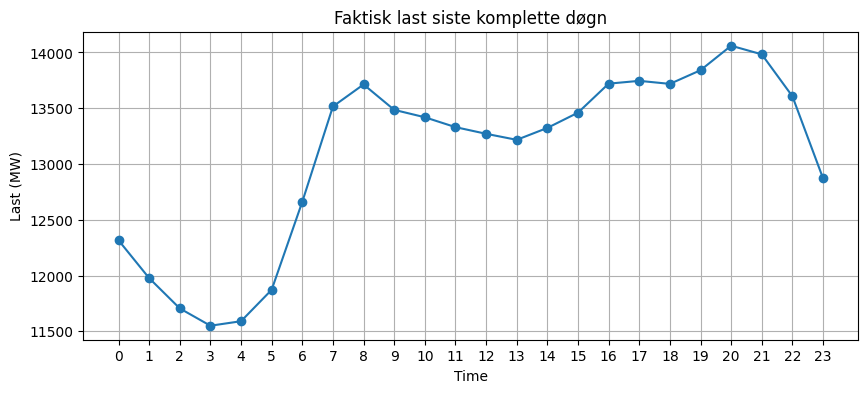

API forespørsel sendt: 2026-09-04 21:47:25
Forespurt intervall: 2026-09-03 00:00:00+02:00 -> 2026-09-04 00:00:00+02:00
Første målepunkt: 2026-09-03 00:00:00+02:00
Siste målepunkt: 2026-09-03 23:45:00+02:00
Analyserer siste komplette døgn: 2026-09-03
Antall målepunkter: 96
Hentet 96 målepunkter
Responstid: 0.00 sekunder
                           Actual Load
2026-09-03 00:00:00+02:00   12316.2625
2026-09-03 01:00:00+02:00   11976.9975
2026-09-03 02:00:00+02:00   11705.5700
2026-09-03 03:00:00+02:00   11550.2700
2026-09-03 04:00:00+02:00   11590.6100
2026-09-03 05:00:00+02:00   11872.4000
2026-09-03 06:00:00+02:00   12661.3875
2026-09-03 07:00:00+02:00   13515.6700
2026-09-03 08:00:00+02:00   13712.9975
2026-09-03 09:00:00+02:00   13485.3175
2026-09-03 10:00:00+02:00   13418.9975
2026-09-03 11:00:00+02:00   13330.4250
2026-09-03 12:00:00+02:00   13270.7425
2026-09-03 13:00:00+02:00   13216.6225
2026-09-03 14:00:00+02:00   13323.4800
2026-09-03 15:00:00+02:00   13460.2175
2026-09-03 16:00

In [31]:
from dotenv import load_dotenv
import os
import pandas as pd
from entsoe import EntsoePandasClient
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import time

load_dotenv("../.env")

client = EntsoePandasClient(
    api_key=os.getenv("ENTSOE_API_KEY")
)

today = pd.Timestamp.now(tz="Europe/Oslo").normalize()
start = today - pd.Timedelta(days=1)
end = today

load = client.query_load(
    country_code="NO",
    start=start,
    end=end
)

load_hourly = load.resample("h").mean()

plt.figure(figsize=(10,4))
plt.plot(load_hourly.index.hour,
         load_hourly.values,
         marker="o")

plt.title("Faktisk last siste komplette døgn")
plt.xlabel("Time")
plt.ylabel("Last (MW)")
plt.xticks(range(24))
plt.grid(True)
plt.show()



request_time = datetime.now()
tic = time.perf_counter()

#load = client.query_load(
#    country_code="NO",
#    start=start,
#    end=end
#)

toc = time.perf_counter()

print(f"API forespørsel sendt: {request_time:%Y-%m-%d %H:%M:%S}")
print(f"Forespurt intervall: {start} -> {end}")
print(f"Første målepunkt: {load.index.min()}")
print(f"Siste målepunkt: {load.index.max()}")
print(f"Analyserer siste komplette døgn: "f"{start.strftime('%Y-%m-%d')}")
print(f"Antall målepunkter: {len(load)}")
print(f"Hentet {len(load)} målepunkter")
print(f"Responstid: {toc - tic:.2f} sekunder")
print(load_hourly)

### Beregning av standardavvik

Standardavviket er et mål på hvor mye observasjonene varierer rundt gjennomsnittet. Et stort standardavvik betyr at verdiene varierer mye, mens et lite standardavvik betyr at verdiene ligger nær gjennomsnittet.

For en dataserie $x_1, x_2, \ldots, x_n$ beregnes utvalgsstandardavviket som

$$
s=\sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

der

- $x_i$ er observasjonene,
- $\bar{x}$ er gjennomsnittet,
- n er antall observasjoner.

I Python kan standardavviket for lastdata beregnes med:

In [3]:
mean = load_hourly.iloc[:, 0].mean()
std = load_hourly.iloc[:, 0].std()

print(f"Gjennomsnitt = {mean:.1f} MW")
print(f"Standardavvik = {std:.1f} MW")

Gjennomsnitt = 13473.9 MW
Standardavvik = 800.7 MW


# Typisk døgnprofil (Norge)

## Modellering av døgnlast

Tidsserien viser en typisk døgnprofil for elektrisk belastning:

- Lavest last om natten, rundt kl. 03-05.
- Kraftig økning om morgenen.
- En tydelig topp på formiddagen.
- Et mindre fall midt på dagen.
- En ny topp om kvelden.
- Avtakende last utover natten.

For å beskrive dette mønsteret kan vi bruke en modell som består av en grunnlast og to Gauss-kurver:

$$
L(t)=L_0+A_1\exp\left(-\frac{(t-\mu_1)^2}{2\sigma_1^2}\right)
+A_2\exp\left(-\frac{(t-\mu_2)^2}{2\sigma_2^2}\right)
$$

der

- $L_0$ er grunnlasten,
- $A_1$ og $A_2$ er høyden på toppene,
- $\mu_1$ og $\mu_2$ er tidspunktet for toppene,
- $\sigma_1$ og $\sigma_2$ beskriver bredden på toppene.

Basert på observasjonene kan vi estimere:

- Grunnlast: ca. 11 900 MW
- Morgentopp: ca. 2 200 MW ved kl. 08
- Kveldstopp: ca. 2 300 MW ved kl. 20

I Python kan modellen skrives som:

```python
t = np.linspace(0, 23, 200)

base_load = 11900

morning_peak = 2200 * np.exp(-0.5*((t-8)/2.5)**2)
evening_peak = 2300 * np.exp(-0.5*((t-20)/4.5)**2)

model_load = (
    base_load
    + morning_peak
    + evening_peak
)
```

Modellen representerer en enkel form for ikke-lineær regresjon der belastningen beskrives som summen av flere komponenter. Parametrene kan estimeres manuelt fra data eller automatisk ved hjelp av statistiske metoder som minste kvadraters metode og funksjonen `curve_fit` i SciPy.

Ved å sammenligne modellen med observerte data kan vi undersøke hvor godt modellen beskriver virkeligheten og beregne mål som residualer, RMSE og forklaringsgrad.

In [52]:
morning_peak = 2200 * np.exp(-0.5*((9-8)/2.5)**2)
print(morning_peak)

2030.8559620505987


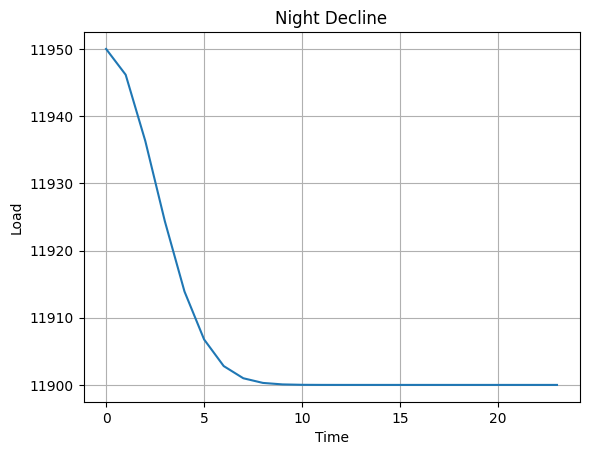

In [53]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(24)

#morning_peak = 2200 * np.exp(-0.5*((x-8)/2.5)**2)
#evening_peak = 2300 * np.exp(-0.5*((x-20)/4.5)**2)
night_decline = 50 * np.exp(-0.5*(x/2.5)**2)

base_load = 11900
plt.plot(x, night_decline+base_load)
plt.xlabel("Time")
plt.ylabel("Load")
plt.title("Night Decline")
plt.grid(True)
plt.show()

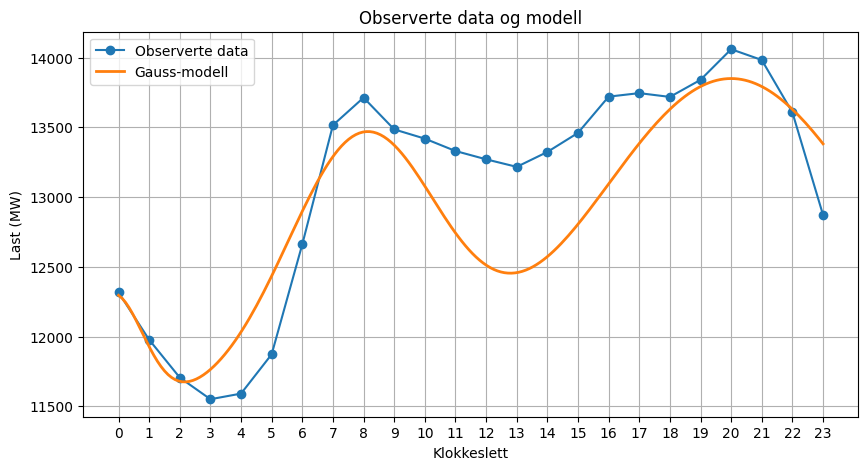

In [46]:
import matplotlib.pyplot as plt
import numpy as np

t = np.linspace(0, 23, 200)

base_load = 11500

night_decline = 800 * np.exp(-0.5*(t+2/10)**2)
morning_peak = 1900 * np.exp(-0.5*((t-8)/2.5)**2)
evening_peak = 2350 * np.exp(-0.5*((t-20)/4.5)**2)

model_load = (
    base_load
    + night_decline
    + morning_peak
    + evening_peak
)

hours = np.arange(24)

plt.figure(figsize=(10, 5))

plt.plot(
    load_hourly.index.hour,
    load_hourly.values,
    "o-",
    label="Observerte data"
)

plt.plot(
    t,
    model_load,
    linewidth=2,
    label="Gauss-modell"
)

plt.xlabel("Klokkeslett")
plt.ylabel("Last (MW)")
plt.title("Observerte data og modell")
plt.xticks(range(24))
plt.grid(True)
plt.legend()

plt.show()

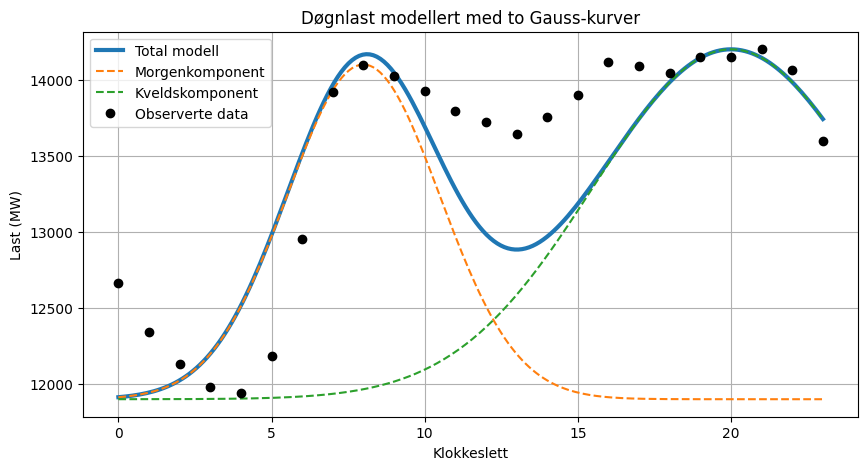

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(t, model_load, label="Total modell", linewidth=3)
plt.plot(t, base_load + morning_peak, "--", label="Morgenkomponent")
plt.plot(t, base_load + evening_peak, "--", label="Kveldskomponent")

plt.plot(
    load_hourly.index.hour,
    load_hourly.values,
    "ko",
    label="Observerte data"
)

plt.xlabel("Klokkeslett")
plt.ylabel("Last (MW)")
plt.title("Døgnlast modellert med to Gauss-kurver")
plt.grid(True)
plt.legend()

plt.show()

## Hva ser vi?

- Morgenpeak rundt kl. 08  
- Kveldspeak rundt kl. 18  
- Lav last om natten 

### Begrensninger ved modellen

Modellen ble utviklet for å beskrive et bestemt døgns belastningsprofil. Når modellen sammenlignes med nye observasjoner fra ENTSO-E, vil man se at den ikke treffer perfekt. Dette illustrerer at alle modeller er forenklinger av virkeligheten.

Dersom modellen brukes på flere døgn gjennom året, vil avvikene ofte øke. Lasten påvirkes blant annet av temperatur, ukedag, sesong, ferier og økonomisk aktivitet, faktorer som ikke er inkludert i modellen.

En slik sammenligning viser hvordan en modell kan være nyttig for å beskrive hovedtrekkene i dataene, samtidig som den inneholder systematiske skjevheter (bias) og tilfeldige avvik (residualer).

## Diskusjon: Modellering av elektrisk belastning

Ved å sammenligne en enkel modell med oppdaterte data fra ENTSO-E kan vi undersøke hvor godt modellen beskriver virkeligheten. Dette gir flere interessante problemstillinger innen statistikk og dataanalyse.

### 1. Bias (systematiske feil)

Bias oppstår når modellen systematisk overvurderer eller undervurderer belastningen.

**Diskusjonsspørsmål:**

- Er modellen gjennomgående for høy eller for lav?
- Er avvikene størst om natten, dagen eller kvelden?
- Hva kan være årsaken til systematiske feil?

### 2. Residualer

Residualen er forskjellen mellom observert verdi og modellert verdi:

$$
\text{Residual} = \text{Observert verdi} - \text{Modellverdi}
$$

Residualene inneholder informasjon om hva modellen ikke klarer å forklare.

**Diskusjonsspørsmål:**

- Er residualene tilfeldig fordelt?
- Finnes det mønstre i residualene?
- Hvilke faktorer kan forklare residualene?

### 3. Modellens antakelser

Modellen antar at belastningen kan beskrives ved hjelp av en grunnlast og to Gauss-formede topper.

**Diskusjonsspørsmål:**

- Er dette en rimelig beskrivelse av virkeligheten?
- Hvilke deler av kurven beskrives godt?
- Hvilke deler beskrives dårlig?

### 4. Generalisering

Modellen er utviklet på bakgrunn av ett bestemt døgn.

**Diskusjonsspørsmål:**

- Fungerer modellen like godt neste dag?
- Fungerer modellen om vinteren?
- Hvordan påvirker ukedager og helger modellens kvalitet?

### 5. Modellkompleksitet

En enkel modell er lett å forstå, men kan gi store avvik. En mer kompleks modell kan gi bedre tilpasning.

**Diskusjonsspørsmål:**

- Hvor mange komponenter bør modellen inneholde?
- Når blir modellen for kompleks?
- Hva er fordeler og ulemper med en enkel modell?

### 6. Overtilpasning og undertilpasning

En modell kan være for enkel eller for spesialisert.

- **Undertilpasning (underfitting):** Modellen er for enkel og klarer ikke å beskrive viktige mønstre.
- **Overtilpasning (overfitting):** Modellen tilpasses ett datasett svært godt, men fungerer dårlig på nye data.

**Diskusjonsspørsmål:**

- Hvilke tegn tyder på undertilpasning?
- Hvilke tegn tyder på overtilpasning?
- Hvordan kan vi teste modellens evne til å generalisere?

```{figure} ../images/bias_variance.svg
---
width: 900px
name: fig-biasvariance
---
Illustrasjon av overtilpasning og undertilpasning
```

### 7. Tidens betydning

Dataene hentes automatisk fra ENTSO-E hver gang notatboken eller Jupyter Book bygges.

**Diskusjonsspørsmål:**

- Hvordan endres belastningskurven fra dag til dag?
- Er modellen fortsatt relevant etter en uke?
- Hva skjer dersom vi sammenligner sommer- og vinterdata?

### 8. Statistikk i praksis

Sammenligningen mellom modell og virkelige data illustrerer et sentralt prinsipp i statistikk:

> Alle modeller er feil, men noen modeller er nyttige.

Målet er ikke nødvendigvis å få en perfekt modell, men å utvikle en modell som forklarer de viktigste trekkene i dataene og samtidig gir innsikt i fenomenet som studeres.

## Bias-variance trade-off

Når vi sammenligner modellen med observerte lastdata, ser vi at modellen ikke treffer perfekt. Dette er normalt og illustrerer et sentralt prinsipp innen statistikk og maskinlæring: bias-variance trade-off.

bias_variance.png

En svært enkel modell vil ofte ha høy bias. Modellen klarer da ikke å beskrive viktige mønstre i dataene og vil systematisk gjøre feil.

En svært kompleks modell vil ofte ha høy varians. Modellen tilpasser seg treningsdataene svært godt, men presterer dårlig på nye observasjoner.

Målet er å finne en modell med passende kompleksitet som gir god generalisering til nye data.

### Refleksjonsspørsmål

- Er Gauss-modellen vår for enkel?
- Hvilke mønstre i lastdataene klarer modellen ikke å beskrive?
- Hva ville skjedd dersom vi la til flere topper eller flere parametere?
- Ville modellen blitt bedre, eller risikerer vi overtilpasning?
- Er modellen som ble utviklet basert på ett døgn fortsatt relevant en uke senere?
- Hvordan påvirkes modellen av temperatur, årstid og ukedag?

I statistikk er målet ofte ikke å finne en perfekt modell, men en modell som beskriver de viktigste trekkene i dataene på en robust måte.

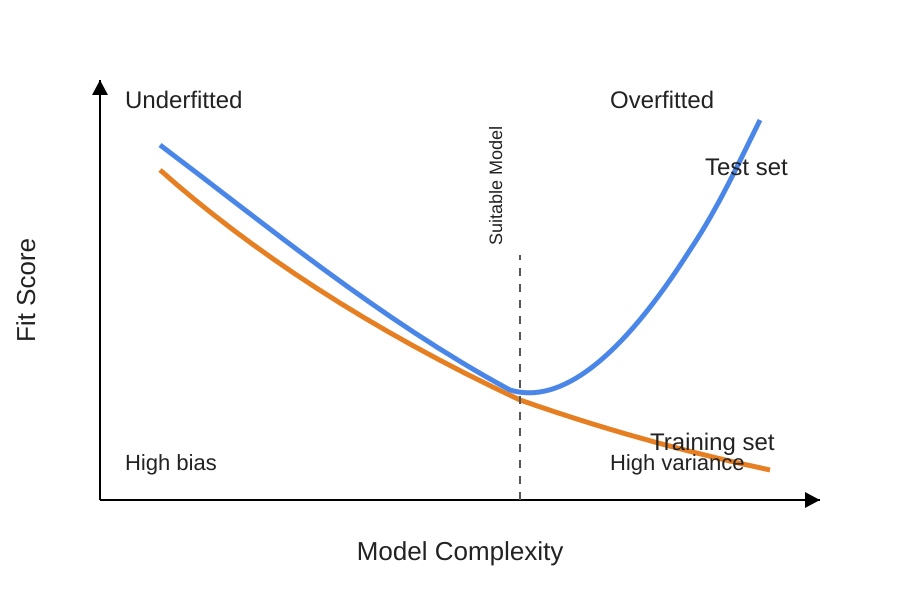

In [11]:
from IPython.display import SVG, display

display(SVG("../images/bias_variance.svg"))

## Forklaring av bias-variance-figuren

Figuren illustrerer hvordan modellens kompleksitet påvirker evnen til å beskrive eksisterende data og generalisere til nye data.

### Den horisontale aksen

Den horisontale aksen viser **modellkompleksitet**.

- Til venstre finner vi enkle modeller.
- Til høyre finner vi mer kompliserte modeller med flere parametere og større fleksibilitet.

### Den vertikale aksen

Den vertikale aksen viser modellens **ytelse (fit score)**.

Høyere verdi betyr bedre tilpasning til dataene.

### Training set-kurven

Den oransje kurven viser ytelsen på **treningsdataene**.

Etter hvert som modellen blir mer kompleks, blir den stadig bedre til å beskrive dataene den er trent på.

Derfor stiger treningsytelsen kontinuerlig med økende modellkompleksitet.

### Test set-kurven

Den blå kurven viser ytelsen på **testdataene**, altså data modellen ikke har sett tidligere.

I starten forbedres ytelsen når modellen blir mer kompleks fordi modellen klarer å fange opp flere viktige mønstre.

Etter et visst punkt begynner ytelsen å bli dårligere. Modellen lærer da ikke bare de underliggende mønstrene, men også støy og tilfeldige variasjoner i treningsdataene.

Dette fenomenet kalles **overtilpasning (overfitting)**.

### Underfitting

Til venstre i figuren finner vi området merket **Underfitted**.

Her er modellen for enkel til å beskrive datasettet.

Kjennetegn:

- Høy bias
- Dårlig ytelse på både trenings- og testdata
- Viktige mønstre blir ikke fanget opp

### Overfitting

Til høyre i figuren finner vi området merket **Overfitted**.

Her er modellen så kompleks at den tilpasser seg tilfeldige detaljer i treningsdataene.

Kjennetegn:

- Høy varians
- Svært god ytelse på treningsdata
- Dårligere ytelse på nye data

### Suitable Model

Den stiplede vertikale linjen markerer den **passende modellen**.

Her er balansen mellom bias og varians best.

Modellen:

- forklarer viktige mønstre i dataene,
- generaliserer godt til nye observasjoner,
- unngår både undertilpasning og overtilpasning.

### Kobling til ENTSO-E-eksemplet

Når vi modellerer døgnlast med en enkel modell som

$$
\text{Last}(t)=\text{grunnlast}+\text{morgentopp}+\text{kveldstopp},
$$

ligger vi relativt langt mot venstre i figuren.

Modellen er enkel å forstå og forklare, men den vil ikke kunne beskrive alle variasjonene i de virkelige ENTSO-E-dataene.

Hvis vi derimot legger til stadig flere topper, parametere og justeringer for å få perfekt samsvar med ett bestemt døgn, beveger vi oss mot høyre i figuren og risikerer overtilpasning.

Figuren illustrerer derfor et sentralt mål i statistikk:

> Målet er ikke å finne den mest kompliserte modellen eller den som passer ett datasett perfekt, men den modellen som gir best generalisering til nye observasjoner.

## Bias og varians

Bias og varians er to sentrale begreper innen statistisk modellering og maskinlæring. De beskriver to ulike typer feil som kan oppstå når vi bruker en modell til å beskrive eller predikere data.

### Bias

Bias er den systematiske feilen i modellen.

En modell med høy bias er ofte for enkel og klarer ikke å beskrive de viktigste mønstrene i dataene. Modellen gjør de samme feilene om og om igjen.

Høy bias fører ofte til:

- undertilpasning (underfitting),
- dårlig ytelse på både treningsdata og testdata,
- systematiske avvik mellom modell og virkelighet.

Eksempel:

Hvis vi modellerer døgnlasten med kun én sinuskurve,

$$
L(t)=A+B\sin(t),
$$

vil modellen ofte være for enkel til å beskrive både morgen- og kveldstoppen i de observerte dataene. Modellen har da høy bias.

### Varians

Varians beskriver hvor følsom modellen er for endringer i datasettet.

En modell med høy varians tilpasser seg treningsdataene svært godt, men reagerer kraftig på små endringer i dataene.

Høy varians fører ofte til:

- overtilpasning (overfitting),
- svært god ytelse på treningsdata,
- dårlig generalisering til nye data.

Eksempel:

Hvis vi lager en svært kompleks modell som passer perfekt til ett bestemt døgn med ENTSO-E-data, kan modellen begynne å tilpasse seg tilfeldige variasjoner og målefeil. Modellen fungerer da dårlig når vi prøver å bruke den på neste døgn.

### Sammenhengen mellom bias og varians

Det er ofte en avveining mellom bias og varians:

| Modelltype | Bias | Varians |
|------------|-------|----------|
| Enkel modell | Høy | Lav |
| Kompleks modell | Lav | Høy |

Når modellkompleksiteten øker:

- Bias reduseres.
- Variansen øker.

Målet er å finne en balanse mellom de to.

### Bias-variance trade-off

Den beste modellen er ofte ikke den enkleste eller den mest kompliserte.

En god modell:

- beskriver de viktigste strukturene i dataene,
- unngår å lære tilfeldige variasjoner,
- generaliserer godt til nye observasjoner.

Dette punktet kalles ofte den optimale balansen mellom bias og varians.

### Kobling til døgnlastmodellen

Når vi modellerer belastningen som

$$
\text{Last}(t)=\text{grunnlast}+\text{morgentopp}+\text{kveldstopp},
$$

må vi gjøre en avveining:

- En svært enkel modell gir høy bias fordi den ikke fanger alle mønstrene i lastdataene.
- En svært komplisert modell gir høy varians fordi den tilpasser seg ett bestemt døgn for godt.

Målet er å finne en modell som beskriver hovedtrekkene i belastningskurven samtidig som den fungerer godt på nye døgn med andre værforhold, sesonger og forbruksmønstre.

> En modell med høy bias lærer for lite av dataene. En modell med høy varians lærer for mye av dataene. En god modell lærer akkurat nok.

## Bias og varians

Bias og varians er to sentrale begreper innen statistisk modellering og maskinlæring. De beskriver to ulike kilder til prediksjonsfeil.

### Matematisk utgangspunkt

Anta at vi ønsker å modellere en sammenheng

$$
Y=f(X)+\varepsilon,
$$

der

- f(X) er den sanne sammenhengen,
- $\varepsilon$ er tilfeldig støy med

$$
E[\varepsilon]=0
$$

og

$$
\text{Var}(\varepsilon)=\sigma^2.
$$

Vi bruker en modell $\hat{f}(X)$ til å estimere den ukjente funksjonen f(X).

### Bias

Bias beskriver den systematiske forskjellen mellom den sanne funksjonen og modellens forventede prediksjon:

$$
\text{Bias}(\hat{f}(x))
=
E[\hat{f}(x)] - f(x).
$$

Hvis bias er stor, vil modellen konsekvent over- eller underestimere den sanne verdien.

Bias måler derfor hvor gode modellens grunnleggende antakelser er.

#### Høy bias

Høy bias oppstår ofte når modellen er for enkel.

Eksempel:

- Lineær modell brukt på en sterkt ikke-lineær sammenheng.
- Én sinuskurve brukt til å beskrive en lastprofil med både morgen- og kveldstopp.

Konsekvenser:

- Undertilpasning (underfitting)
- Dårlig ytelse på både trenings- og testdata
- Systematiske feil

### Varians

Varians beskriver hvor mye modellen varierer dersom vi trener den på nye datasett fra samme prosess.

Matematisk:

$$
\text{Var}(\hat{f}(x))
=
E\left[
\left(
\hat{f}(x)-E[\hat{f}(x)]
\right)^2
\right].
$$

En modell med høy varians er svært følsom for små endringer i treningsdataene.

#### Høy varians

Høy varians oppstår ofte når modellen er svært kompleks.

Eksempel:

- Mange parametere.
- Svært komplekse nevrale nettverk.
- En modell som forsøker å passe perfekt til hvert målepunkt i ett bestemt døgn.

Konsekvenser:

- Overtilpasning (overfitting)
- Svært god ytelse på treningsdata
- Dårlig generalisering til nye data

### Bias-variance-dekomponeringen

For kvadratisk tap kan forventet prediksjonsfeil skrives som

$$
E
\left[
(\hat{f}(x)-Y)^2
\right]
=
\underbrace{\text{Bias}^2}_{\text{systematisk feil}}
+
\underbrace{\text{Varians}}_{\text{følsomhet}}
+
\underbrace{\sigma^2}_{\text{støy}}
$$

Dette er den klassiske **bias-variance-dekomponeringen**.

Den viser at den totale prediksjonsfeilen består av tre deler:

1. Bias²
2. Varians
3. Uunngåelig støy

### Sammenhengen mellom bias og varians

Når modellkompleksiteten øker:

- Bias reduseres.
- Variansen øker.

Når modellkompleksiteten reduseres:

- Bias øker.
- Variansen reduseres.

Dette skaper en avveining, kjent som **bias-variance trade-off**.

### Kobling til døgnlastmodellen

Anta at vi modellerer elektrisk belastning som

$$
L(t)
=
L_0
+
A_1
e^{-\frac{(t-\mu_1)^2}{2\sigma_1^2}}
+
A_2
e^{-\frac{(t-\mu_2)^2}{2\sigma_2^2}}.
$$

Denne modellen består av en grunnlast og to Gauss-formede topper.

- Dersom modellen er for enkel, vil den ikke klare å beskrive alle variasjonene i ENTSO-E-dataene. Dette gir høy bias.
- Dersom vi stadig legger til flere topper og parametere for å tilpasse ett bestemt døgn perfekt, vil modellen få høy varians.

Målet er å finne en modell som beskriver de viktigste mønstrene i belastningsdataene samtidig som den generaliserer godt til nye døgn.

> En modell med høy bias lærer for lite av dataene. En modell med høy varians lærer for mye av dataene. En god modell finner en balanse mellom de to.

Bias skyldes antagelsene vi bygger inn i modellen. Jo enklere modellen er, desto flere forenklinger må vi gjøre, og desto større blir risikoen for systematiske feil.

Varians skyldes modellens fleksibilitet. Jo mer kompleks modellen er, desto bedre kan den tilpasses eksisterende data, men desto større er risikoen for at modellen lærer tilfeldigheter som ikke vil gjenta seg i nye observasjoner.

Bias-variance trade-off handler derfor om balansen mellom forklaringskraft og generalisering.

For de som ønsker en mer matematisk beskrivelse kan den forventede prediksjonsfeilen deles opp i tre komponenter:

$$
\text{Total feil}
=
\text{Bias}^2
+
\text{Varians}
+
\text{Støy}
$$

der

- Bias² beskriver systematiske feil i modellen.
- Varians beskriver modellens følsomhet for endringer i dataene.
- Støy er variasjon som ikke kan forklares av modellen.

### Hva betyr de tre komponentene?

#### Bias²

Bias oppstår når modellen systematisk bommer på virkeligheten.

Eksempel:

$$
\text{Bias}
=
\text{Virkelig verdi}
-
\text{Gjennomsnittlig modellverdi}
$$

Hvis den virkelige lasten er 14 000 MW og modellen i gjennomsnitt predikerer 13 000 MW, får vi

$$
\text{Bias}=1000
$$

og

$$
\text{Bias}^2 = 1000^2.
$$

Bias skyldes ofte forenklede antagelser i modellen.

#### Varians

Varians beskriver hvor mye modellens prediksjoner endrer seg dersom modellen trenes på nye datasett.

En intuitiv representasjon er

$$
\text{Varians}
\approx
m
$$

Stor varians betyr at modellen reagerer kraftig på små endringer i dataene.

#### Støy

Støy er variasjon som ikke kan forklares av modellen.

$$
\text{Støy}
=
\text{Observasjon}
-
\text{Virkelig sammenheng}
$$

Eksempler kan være:

- tilfeldige variasjoner i forbruk,
- målefeil,
- værforhold som ikke inngår i modellen,
- menneskelig atferd.

### Eksempel

Anta at den observerte lasten er

$$
14000\ \text{MW}
$$

og modellen predikerer

$$
13500\ \text{MW}.
$$

Feilen er da

$$
500\ \text{MW}.
$$

Denne feilen kan skyldes:

- bias (modellen er for enkel),
- varians (modellen er tilpasset andre data),
- støy (tilfeldige variasjoner i belastningen).

Dermed kan vi se på den totale prediksjonsfeilen som summen av disse tre bidragene.

## Bias, varians og total feil

La $f(x)$ være den sanne sammenhengen vi ønsker å beskrive, og la $\hat f(x)$ være modellens prediksjon.

### Bias

Bias er den systematiske forskjellen mellom modellens gjennomsnittlige prediksjon og den sanne verdien:

$$
\text{Bias}
=
E[\hat f(x)] - f(x)
$$

Bias måler hvor mye modellen i gjennomsnitt bommer på virkeligheten.

### Varians

Varians beskriver hvor mye modellens prediksjoner varierer dersom modellen trenes på ulike datasett:

$$
\text{Var}(\hat f(x))
=
E\left[
\left(
\hat f(x)-E[\hat f(x)]
\right)^2
\right].
$$

Legg merke til at variansen allerede inneholder et kvadrert avvik.

### Total feil

Den forventede prediksjonsfeilen kan deles opp som

$$
\text{Total feil}
=
\text{Bias}^2
+
\text{Var}(\hat f(x))
+
\sigma^2.
$$

Mer eksplisitt:

$$
E[(Y-\hat f(x))^2]
=
\big(E[\hat f(x)]-f(x)\big)^2
+
E\left[
\left(
\hat f(x)-E[\hat f(x)]
\right)^2
\right]
+
\sigma^2.
$$

der

- $\big(E[\hat f(x)]-f(x)\big)^2$ er bias²,
- $E[(\hat f(x)-E[\hat f(x)])^2]$ er variansen,
- $\sigma^2$ er uunngåelig støy i dataene.

### Tolkning

- **Bias²** oppstår fordi modellen bygger på forenklede antagelser.
- **Varians** oppstår fordi modellen kan bli for følsom for treningsdataene.
- **Støy** er variasjon som ingen modell kan forklare fullt ut.

En enkel modell gir ofte høy bias og lav varians.

En kompleks modell gir ofte lav bias og høy varians.

Målet er å finne en modell som balanserer disse to effektene slik at den totale prediksjonsfeilen blir minst mulig.

### Hva er Y?

I den matematiske formuleringen

$$
E[(Y-\hat f(x))^2]
=
\text{Bias}^2
+
\text{Var}(\hat f(x))
+
\sigma^2
$$

representerer

- Y den observerte verdien,
- $\hat f(x)$ modellens prediksjon,
- $f(x)$ den sanne, men ukjente sammenhengen.

For lastdata fra ENTSO-E kan vi tenke oss at

$$
Y = \text{observert elektrisk last}
$$

og at modellen forsøker å predikere denne lasten ved hjelp av

$$
\hat f(x).
$$




### Eksempel

Anta at den observerte lasten klokken 08 er

$$
Y=14095\ \text{MW}
$$

mens modellen predikerer

$$
\hat f(x)=13800\ \text{MW}.
$$

Da er prediksjonsfeilen

$$
Y-\hat f(x)=295\ \text{MW}.
$$

| Klokkeslett | Observert last $$Y$$ | Modell $$\hat f(x)$$ |
| ----------- | -------------------: | -------------------: |
| 08:00       |             14095 MW |             13800 MW |
| 09:00       |             14022 MW |             13900 MW |
| 10:00       |             13924 MW |             13750 MW |

### Den sanne sammenhengen

Vi antar ofte at observasjonene kan beskrives som

$$
Y=f(x)+\varepsilon,
$$

der

- $f(x)$ er den sanne sammenhengen,
- $\varepsilon$ er tilfeldig støy.

For elektrisk belastning kan den sanne sammenhengen påvirkes av faktorer som:

- klokkeslett,
- temperatur,
- ukedag,
- årstid,
- økonomisk aktivitet.

Modellen forsøker å finne en tilnærming til denne ukjente funksjonen.

### Bias, varians og total feil

Bias beskriver den systematiske forskjellen mellom modellens gjennomsnittlige prediksjon og den sanne sammenhengen:

$$
\text{Bias}
=
E[\hat f(x)] - f(x).
$$

Varians beskriver hvor mye modellens prediksjoner varierer dersom modellen trenes på ulike datasett:

$$
\text{Var}(\hat f(x))
=
E\left[
\left(
\hat f(x)-E[\hat f(x)]
\right)^2
\right]
$$

Den forventede prediksjonsfeilen kan skrives som

$$
E[(Y-\hat f(x))^2]
=
\big(E[\hat f(x)]-f(x)\big)^2
+
E\left[
\left(
\hat f(x)-E[\hat f(x)]
\right)^2
\right]
+
\sigma^2.
$$

Dette uttrykket viser at den totale feilen består av tre komponenter:

$$
\text{Total feil}
=
\text{Bias}^2
+
\text{Varians}
+
\text{Støy}.
$$

- **Bias²** skyldes forenklede antagelser i modellen.
- **Varians** skyldes modellens følsomhet for treningsdataene.
- **Støy** er variasjon som ingen modell kan forklare fullt ut.

For enkle modeller er bias ofte høy og variansen lav.

For svært komplekse modeller er bias ofte lav, men variansen høy.

Målet er å finne en modell som balanserer disse to effektene slik at den totale prediksjonsfeilen blir minst mulig.